# 03 - Cox proportional hazards: driver analysis with a clock

Kaplan-Meier compares groups one at a time. Cox proportional hazards lets us ask:

> Holding other variables constant, which customer characteristics are associated with faster or slower churn?

The output is usually a **hazard ratio**. The hazard at time t is the instantaneous event rate among customers still active at t, so a hazard ratio is a multiplier on the event rate of the survivors at each moment.

- `hazard ratio > 1`: higher instantaneous event rate.
- `hazard ratio < 1`: lower instantaneous event rate.
- `hazard ratio = 1`: no estimated effect.

A hazard ratio is not a probability. It is a multiplier on the event rate at each point in time.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

def find_intro_dir():
    cwd = Path.cwd()
    if cwd.name == "survival-analysis-intro":
        return cwd
    if cwd.name == "notebooks" and cwd.parent.name == "survival-analysis-intro":
        return cwd.parent
    candidate = cwd / "survival-analysis-intro"
    if candidate.exists():
        return candidate
    return cwd

INTRO_DIR = find_intro_dir()
DATA_DIR = INTRO_DIR / "data"

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

In [2]:
churn = pd.read_csv(DATA_DIR / "service_churn_drivers.csv")
churn.head()

,customer_id,plan,industry,seats,monthly_fee,login_days_30,support_tickets_30,discount_pct,training_completed,duration_days,churn_observed
0,S00001,Pro,Manufacturing,5,84.30,15,2,30,1,296,0
1,S00002,Pro,Manufacturing,4,89.26,16,1,20,1,91,1
2,S00003,Basic,Manufacturing,1,47.33,11,4,0,0,69,1
3,S00004,Basic,SaaS,3,60.42,8,2,0,0,128,1
4,S00005,Basic,Manufacturing,5,70.91,4,2,0,0,62,1


In [3]:
churn[["duration_days", "churn_observed", "login_days_30", "support_tickets_30", "discount_pct"]].describe().round(2)

,duration_days,churn_observed,login_days_30,support_tickets_30,discount_pct
count,1600.00,1600.00,1600.00,1600.00,1600.00
mean,180.64,0.49,10.15,1.23,7.12
std,99.89,0.50,4.31,1.15,8.78
min,1.00,0.00,0.00,0.00,0.00
25%,95.00,0.00,7.00,0.00,0.00
50%,186.00,0.00,10.00,1.00,5.00
75%,259.00,1.00,13.00,2.00,10.00
max,365.00,1.00,27.00,9.00,30.00


## Prepare model data

The survival target columns are:

- `duration_days`: how long we observed the customer.
- `churn_observed`: 1 if churn happened, 0 if the row is censored.

Those columns must never be included as predictors. They are the target.

One encoding detail changes how you read every coefficient below: `drop_first=True` silently picks a reference level for each categorical. Here that makes plan=Basic and industry=Healthcare the references, so every plan hazard ratio reads "vs Basic" and every industry hazard ratio reads "vs Healthcare".

In [4]:
from sklearn.model_selection import train_test_split
from lifelines import CoxPHFitter

model_df = churn.drop(columns=["customer_id"]).copy()
model_df = pd.get_dummies(model_df, columns=["plan", "industry"], drop_first=True)

train_df, test_df = train_test_split(
    model_df,
    test_size=0.25,
    random_state=42,
    stratify=model_df["churn_observed"],
)

print("train rows:", len(train_df), "test rows:", len(test_df))
print("train events:", int(train_df["churn_observed"].sum()))
print("train event rate:", round(train_df["churn_observed"].mean(), 3))
print("test event rate:", round(test_df["churn_observed"].mean(), 3))

train rows: 1200 test rows: 400
train events: 593
train event rate: 0.494
test event rate: 0.495


## Fit the model, without a penalty

We fit by plain maximum partial likelihood: no `penalizer`. The training set has 593 events for 11 covariates - about 54 events per variable - which is comfortable territory for an unpenalized fit. Penalization is a tool for the opposite regime, many features and few events. It also has a price: a ridge or lasso penalty biases the coefficients and invalidates the naive standard errors, so if you do penalize, do not quote the resulting p-values and confidence intervals (see the repo's `LESSONS_LEARNED.md`, "Penalized Cox fits don't give valid p-values"). Because this fit is unpenalized, the p-values and CIs below mean what they say.

In [5]:
cph = CoxPHFitter()
cph.fit(train_df, duration_col="duration_days", event_col="churn_observed")

print("Train concordance:", round(cph.concordance_index_, 3))
print("Test concordance:", round(cph.score(test_df, scoring_method="concordance_index"), 3))
cph.summary[["coef", "exp(coef)", "p", "exp(coef) lower 95%", "exp(coef) upper 95%"]].round(3)

Train concordance: 0.72
Test concordance: 0.711


,coef,exp(coef),p,exp(coef) lower 95%,exp(coef) upper 95%
covariate,,,,,
seats,-0.079,0.924,0.049,0.854,1.000
monthly_fee,0.009,1.009,0.076,0.999,1.020
login_days_30,-0.039,0.962,0.007,0.935,0.989
support_tickets_30,0.216,1.240,0.000,1.159,1.328
discount_pct,-0.038,0.962,0.000,0.952,0.973
training_completed,-0.474,0.622,0.000,0.525,0.738
plan_Enterprise,-2.194,0.111,0.003,0.026,0.485
plan_Pro,-0.925,0.396,0.000,0.286,0.550
industry_Manufacturing,-0.076,0.927,0.517,0.736,1.167


In [6]:
hazard_ratios = (
    cph.summary[["exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p"]]
    .rename(columns={"exp(coef)": "hazard_ratio"})
    .sort_values("hazard_ratio", ascending=False)
)
hazard_ratios.assign(
    interpretation=np.select(
        [
            hazard_ratios["exp(coef) lower 95%"] > 1,
            hazard_ratios["exp(coef) upper 95%"] < 1,
        ],
        ["faster churn", "slower churn"],
        default="uncertain (CI spans 1)",
    )
).round(4)

,hazard_ratio,exp(coef) lower 95%,exp(coef) upper 95%,p,interpretation
covariate,,,,,
support_tickets_30,1.2405,1.1586,1.3282,0.0000,faster churn
industry_Retail,1.2079,0.9645,1.5128,0.0999,uncertain (CI spans 1)
industry_SaaS,1.1059,0.8843,1.3830,0.3777,uncertain (CI spans 1)
monthly_fee,1.0094,0.9990,1.0198,0.0756,uncertain (CI spans 1)
discount_pct,0.9624,0.9524,0.9725,0.0000,slower churn
login_days_30,0.9619,0.9353,0.9894,0.0068,slower churn
industry_Manufacturing,0.9267,0.7362,1.1666,0.5170,uncertain (CI spans 1)
seats,0.9240,0.8542,0.9995,0.0486,slower churn
training_completed,0.6224,0.5248,0.7381,0.0000,slower churn


### Reading the ratios at the right scale

A few things to keep straight before quoting any row of that table:

- **A direction label has to be earned by the confidence interval, not the point estimate.** We only say "faster churn" or "slower churn" when the 95% CI excludes 1. The industry dummies and `monthly_fee` stay "uncertain (CI spans 1)"; `seats` clears the bar just barely (upper bound 0.9995, p = 0.049).
- **Per-unit means per unit.** `support_tickets_30` has a hazard ratio of 1.24: in the model, each additional ticket in the last 30 days multiplies the churn hazard by 1.24, i.e. a 24% higher event rate at any given moment, with the other covariates held fixed.
- **`monthly_fee` is per dollar.** That is why it prints as roughly 1.01: one dollar is a tiny step. The same coefficient compounded per $50 is 1.009^50, about 1.59. The unit decides how impressive the number looks; the effect is the same.
- **Fee is nearly determined by plan.** `monthly_fee` and `plan_Enterprise` correlate at about 0.92 in this data, so the model can shuffle credit between them: the dramatic `plan_Enterprise` ratio (0.11 vs Basic) and a fee ratio slightly above 1 are two halves of one entangled story. Read the fee and plan coefficients jointly, not row by row.

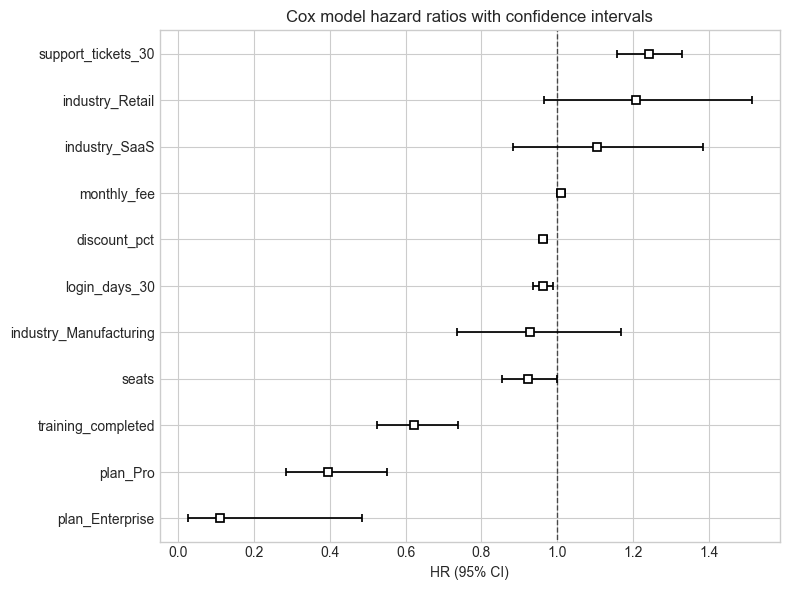

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
cph.plot(hazard_ratios=True, ax=ax)
ax.set_title("Cox model hazard ratios with confidence intervals")
plt.tight_layout()
plt.show()

## The assumption in the name: proportional hazards

Every hazard ratio above carries an assumption: the multiplier is constant over time. The 0.622 for `training_completed` claims a roughly 38% lower event rate in month one and in month eleven alike. That is a checkable assumption, and the standard check is the scaled Schoenfeld residual test below. Treat its p-values as a screen, not a verdict: a small p means "look closer", not "throw the model away". On this fit the screen flags `discount_pct` (p = 0.0049), which suggests its effect drifts over time, so its single hazard ratio is an average over something time-varying. Notebook 04 runs this same diagnostic on this same dataset and works through what to do about the flagged covariate.

In [8]:
from lifelines.statistics import proportional_hazard_test

ph_test = proportional_hazard_test(cph, train_df, time_transform="rank")
ph_test.summary.sort_values("p").round(4)

,test_statistic,p,-log2(p)
discount_pct,7.9309,0.0049,7.6849
support_tickets_30,3.4384,0.0637,3.9727
monthly_fee,2.1316,0.1443,2.7929
login_days_30,2.0661,0.1506,2.7312
industry_SaaS,1.8593,0.1727,2.5336
training_completed,1.7221,0.1894,2.4004
plan_Enterprise,1.6062,0.2050,2.2861
industry_Manufacturing,0.8977,0.3434,1.5421
seats,0.6016,0.4380,1.1912
plan_Pro,0.1678,0.6821,0.5519


## Predict survival curves for two customer profiles

Cox is semi-parametric:

- In the partial likelihood, the baseline hazard is left completely unspecified: the coefficients are estimated without ever committing to its shape. lifelines estimates a baseline afterwards so the model can make predictions.
- Features act multiplicatively on that baseline: S(t) = S0(t)^exp(Xb). A risky profile does not shift the curve down by a constant amount; it exponentiates it.

That lets us compare two realistic personas without claiming that any single coefficient is destiny.

One trap when building personas: when you flip a dummy, adjust the covariates correlated with it, or the persona leaves the support of the data. Setting `plan_Enterprise = 1` while keeping the overall-median fee of about $81 would describe a customer that does not exist - every Enterprise customer in this data pays between $186 and $327. So the enterprise persona below takes its fee and seat count from the medians of the Enterprise rows themselves. Note also that both personas keep every industry dummy at 0, which implicitly places both in the reference industry (Healthcare).

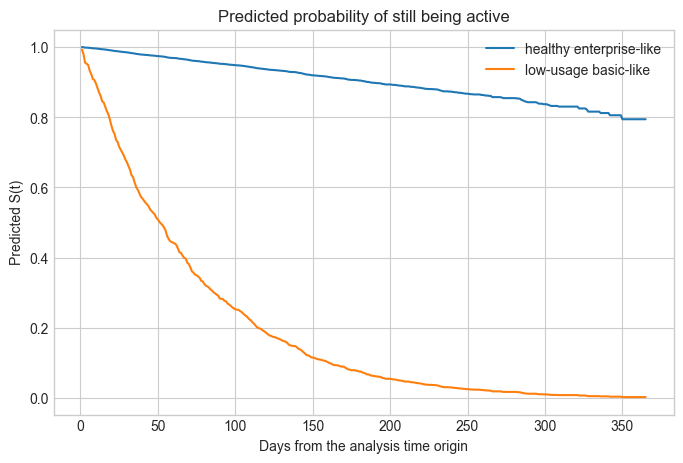

,persona,P(active at day 90),P(active at day 180)
0,healthy enterprise-like,0.952,0.904
1,low-usage basic-like,0.283,0.075


In [9]:
feature_cols = [c for c in train_df.columns if c not in ["duration_days", "churn_observed"]]
reference = train_df[feature_cols].median().to_frame().T

# Enterprise persona: fee and seats come from the Enterprise rows themselves,
# so the profile stays inside the support of the data.
enterprise_rows = train_df[train_df["plan_Enterprise"] == 1]

low_risk = reference.copy()
low_risk["login_days_30"] = 24
low_risk["support_tickets_30"] = 0
low_risk["training_completed"] = 1
low_risk["plan_Enterprise"] = 1
low_risk["plan_Pro"] = 0
low_risk["monthly_fee"] = enterprise_rows["monthly_fee"].median()
low_risk["seats"] = enterprise_rows["seats"].median()

# Basic persona: the overall medians (a ~$81 fee, 4 seats) already sit inside
# the Basic plan's observed range, so they can stay.
high_risk = reference.copy()
high_risk["login_days_30"] = 2
high_risk["support_tickets_30"] = 4
high_risk["training_completed"] = 0
high_risk["plan_Enterprise"] = 0
high_risk["plan_Pro"] = 0

personas = pd.concat([low_risk, high_risk], ignore_index=True)
personas.index = ["healthy enterprise-like", "low-usage basic-like"]

survival = cph.predict_survival_function(personas, times=np.arange(1, 366))
ax = survival.plot(figsize=(8, 5))
ax.set_title("Predicted probability of still being active")
ax.set_xlabel("Days from the analysis time origin")
ax.set_ylabel("Predicted S(t)")
plt.show()

pd.DataFrame({
    "persona": personas.index,
    "P(active at day 90)": cph.predict_survival_function(personas, times=[90]).T[90].round(3).values,
    "P(active at day 180)": cph.predict_survival_function(personas, times=[180]).T[180].round(3).values,
})

## What to say in a business review

Strong version:

> After controlling for plan, industry, seats, discount, and training completion, low product usage and more support tickets are associated with faster churn. The model separates higher-risk from lower-risk customers on a held-out test set (concordance about 0.71), and the survival curves translate that into expected retention at 90 and 180 days.

Weak version:

> The model says support tickets cause churn.

Cox can support driver analysis, but causal language requires experiment design or much stronger assumptions.